In [1]:
import numpy as np
import pandas as pd

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# df = pd.read_csv("df.csv")
# df.to_csv("df.csv", index = False)
# hdf.to_csv("hdf.csv", index = False)

In [38]:
df = pd.read_csv("dataset.csv")

In [39]:
print(df.columns)
ndf = df.dropna()

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


In [40]:
df.dropna(inplace = True)
chinese_artists_idx = df['Unnamed: 0'][~df['artists'].str.contains(r"[A-za-z]+")].to_list()
chinese_album_idx = df['Unnamed: 0'][~df['album_name'].str.contains(r"[A-za-z]+")].to_list()
chinese_track_idx = df['Unnamed: 0'][~df['track_name'].str.contains(r"[A-za-z]+")].to_list()
df['track_genre'][~df['track_genre'].str.contains(r"[A-za-z]+")]

Series([], Name: track_genre, dtype: object)

In [41]:
numerical_column_list = [
    'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'
]

print("=" * 40)
print(f"|{'Numerical Column Name':^25} | {'DataType':^10}|")
print("=" * 40)

for num_col in numerical_column_list:
    print(f"|{num_col:^25} | {str(df[num_col].dtype):^10}|")
    print("-" * 40)

|  Numerical Column Name   |  DataType |
|       popularity         |   int64   |
----------------------------------------
|       duration_ms        |   int64   |
----------------------------------------
|        explicit          |    bool   |
----------------------------------------
|      danceability        |  float64  |
----------------------------------------
|         energy           |  float64  |
----------------------------------------
|           key            |   int64   |
----------------------------------------
|        loudness          |  float64  |
----------------------------------------
|          mode            |   int64   |
----------------------------------------
|       speechiness        |  float64  |
----------------------------------------
|      acousticness        |  float64  |
----------------------------------------
|    instrumentalness      |  float64  |
----------------------------------------
|        liveness          |  float64  |
----------------

In [42]:
chinese_songs_idx = []
chinese_songs_idx.extend(chinese_artists_idx)
chinese_songs_idx.extend(chinese_album_idx)
chinese_songs_idx.extend(chinese_track_idx)
chinese_songs_idx = set(chinese_songs_idx)
df.drop(index = chinese_songs_idx, inplace = True)

In [35]:
hdf = df[['track_id', 'track_name']]
df.drop(columns = ['Unnamed: 0', 'track_name'], inplace = True)

In [46]:
hdf

,track_id,track_name
0,5SuOikwiRyPMVoIQDJUgSV,Comedy
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love
4,5vjLSffimiIP26QG5WcN2K,Hold On
...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Sleep My Little Boy
113996,1hIz5L4IB9hN3WRYPOCGPw,Water Into Light
113997,6x8ZfSoqDjuNa5SVP5QjvX,Miss Perfumado
113998,2e6sXL2bYv4bSz6VTdnfLs,Friends


In [33]:
df.columns

Index(['track_id', 'artists', 'album_name', 'popularity', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [64]:
num_col = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
corr_mat = df[num_col].corr()

In [48]:
corr_mat[((corr_mat > 0.5) | (corr_mat < -0.5)) & (corr_mat != 1.0)] 

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
explicit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,NaN,NaN,NaN,0.760523,NaN,NaN,-0.729771,NaN,NaN,NaN,NaN,NaN
key,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loudness,NaN,NaN,NaN,NaN,0.760523,NaN,NaN,NaN,NaN,-0.588923,NaN,NaN,NaN,NaN,NaN
mode,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,NaN,-0.729771,NaN,-0.588923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

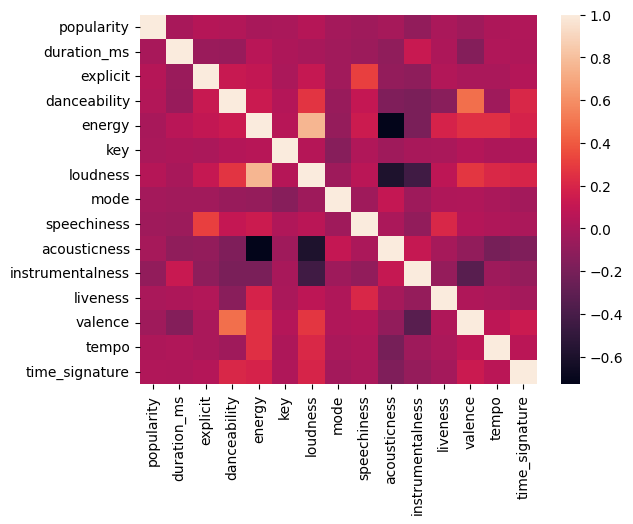

In [49]:
sns.heatmap(corr_mat)

In [65]:
#because correlation between corr(energy, loudness) and corr(energy, acousticness)
df.drop(columns = ["loudness", "acousticness"], inplace = True)

In [50]:
df.columns

Index(['track_id', 'artists', 'album_name', 'popularity', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [20]:
df.value_counts(['album_name', 'artists', 'track_genre']) 

album_name                                       artists            track_genre
The Complete Hank Williams                       Hank Williams      honky-tonk     85
Dora The Explorer                                Dora The Explorer  kids           42
Nursery Rhymes by CoComelon                      CoComelon          children       40
Black Adam (Original Motion Picture Soundtrack)  Lorne Balfe        british        38
The Hardcore Archive Part 3 (1997)               The Prophet        happy          36
                                                                                   ..
Halloween 2022                                   Marilyn Manson     alt-rock        1
                                                                    alternative     1
                                                                    industrial      1
                                                                    metal           1
당신이 잠든 사이에 Pt. 4 Original Television Soundtrack  Suzy       

In [25]:
df.value_counts(['album_name', 'artists', 'track_genre'])[df.value_counts(['album_name', 'artists', 'track_genre']) > 1]

album_name                                                            artists                           track_genre
The Complete Hank Williams                                            Hank Williams                     honky-tonk     85
Dora The Explorer                                                     Dora The Explorer                 kids           42
Nursery Rhymes by CoComelon                                           CoComelon                         children       40
Black Adam (Original Motion Picture Soundtrack)                       Lorne Balfe                       british        38
The Hardcore Archive Part 3 (1997)                                    The Prophet                       happy          36
                                                                                                                       ..
Beloved Antichrist                                                    Therion                           black-metal     2
Rehnaa Hai Terre Dil Mein     

In [26]:
df.value_counts(['album_name', 'artists']) 

album_name                                                     artists                         
The Complete Hank Williams                                     Hank Williams                       85
The Hardcore Archive Part 3 (1997)                             The Prophet                         70
Schumann, Poulenc & Others: Piano Works (Live in Japan, 2022)  Robert Schumann;Pavel Nersessian    52
Serenity                                                       Little Symphony                     51
The Way That Lovers Do                                         Prateek Kuhad                       48
                                                                                                   ..
Hôtel Costes 2 - La Suite                                      Boozoo Bajou                         1
                                                               De-Phazz                             1
                                                               Femi Kuti                

In [27]:
df.value_counts(['album_name', 'artists'])[df.value_counts(['album_name', 'artists']) > 1]

album_name                                                     artists                             
The Complete Hank Williams                                     Hank Williams                           85
The Hardcore Archive Part 3 (1997)                             The Prophet                             70
Schumann, Poulenc & Others: Piano Works (Live in Japan, 2022)  Robert Schumann;Pavel Nersessian        52
Serenity                                                       Little Symphony                         51
The Way That Lovers Do                                         Prateek Kuhad                           48
                                                                                                       ..
The Look - R&B Feels                                           Bruno Mars;Anderson .Paak;Silk Sonic     2
laugh at the balance                                           meadowzz                                 2
Valencianas (Ao Vivo)                               

In [29]:
df['artists'].value_counts()

artists
The Beatles                                           279
George Jones                                          271
Stevie Wonder                                         236
Linkin Park                                           224
Ella Fitzgerald                                       222
                                                     ... 
RoelBeat;Goodiny                                        1
GeoM;Marc Philippe                                      1
Matvey Emerson;NEVRMIND                                 1
Novo Som;Mattos Nascimento;Coral Unidade em Cristo      1
Jesus Culture                                           1
Name: count, Length: 30525, dtype: int64

In [69]:
# because each col contains more category than combined columns so we apply 
freq_cols = ['album_name', 'artists', 'track_genre']

for freq_col in freq_cols:
    freq = df[freq_col].value_counts()
    df[f'{freq_col}_pop'] = df[freq_col].map(freq)

In [71]:
df.drop(columns = ['album_name', 'artists', 'track_genre'], inplace = True)

In [72]:
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,mode,speechiness,instrumentalness,liveness,valence,tempo,time_signature,album_name_pop,artists_pop,track_genre_pop
0,5SuOikwiRyPMVoIQDJUgSV,73,230666,False,0.676,0.4610,1,0,0.1430,0.000001,0.3580,0.7150,87.917,4,4,10,940
1,4qPNDBW1i3p13qLCt0Ki3A,55,149610,False,0.420,0.1660,1,1,0.0763,0.000006,0.1010,0.2670,77.489,4,2,13,940
2,1iJBSr7s7jYXzM8EGcbK5b,57,210826,False,0.438,0.3590,0,1,0.0557,0.000000,0.1170,0.1200,76.332,4,1,1,940
3,6lfxq3CG4xtTiEg7opyCyx,71,201933,False,0.266,0.0596,0,1,0.0363,0.000071,0.1320,0.1430,181.740,3,1,15,940
4,5vjLSffimiIP26QG5WcN2K,82,198853,False,0.618,0.4430,2,1,0.0526,0.000000,0.0829,0.1670,119.949,4,6,11,940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,21,384999,False,0.172,0.2350,5,1,0.0422,0.928000,0.0863,0.0339,125.995,5,4,4,999
113996,1hIz5L4IB9hN3WRYPOCGPw,22,385000,False,0.174,0.1170,0,0,0.0401,0.976000,0.1050,0.0350,85.239,4,4,4,999
113997,6x8ZfSoqDjuNa5SVP5QjvX,22,271466,False,0.629,0.3290,0,0,0.0420,0.000000,0.0839,0.7430,132.378,4,26,14,999
113998,2e6sXL2bYv4bSz6VTdnfLs,41,283893,False,0.587,0.5060,7,1,0.0297,0.000000,0.2700,0.4130,135.960,4,2,30,999


In [37]:
num_cols = ['track_id', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'mode', 'speechiness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'album_name_pop', 'artists_pop']

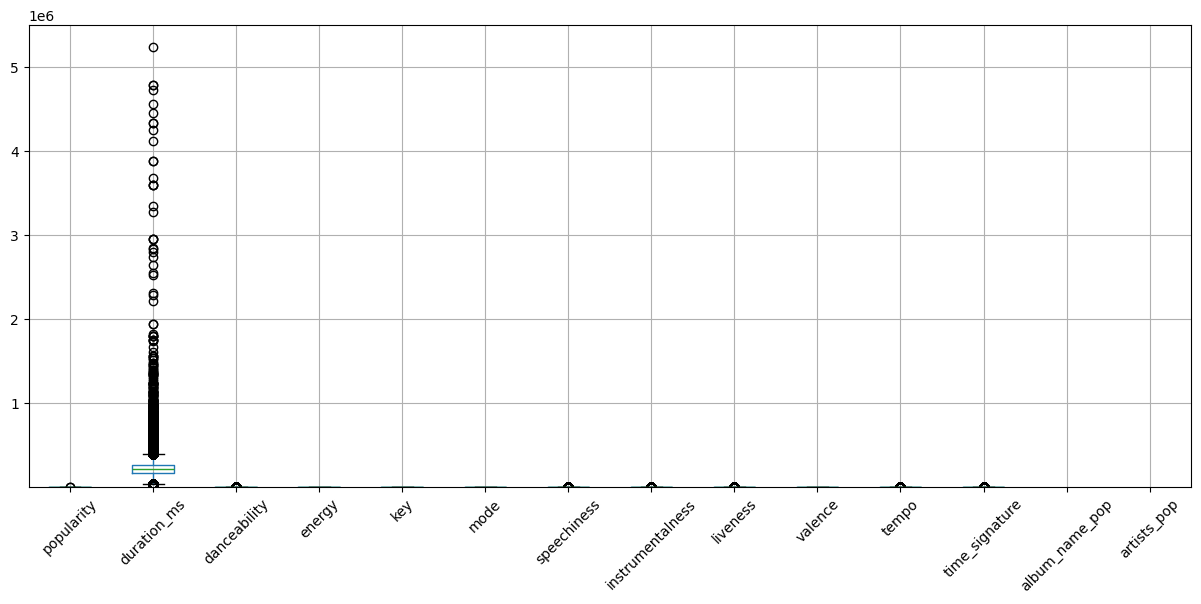

In [39]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(15,6))
num_df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [10]:
df[df['duration_ms'] <= 15000]

,track_id,popularity,duration_ms,explicit,danceability,energy,key,mode,speechiness,instrumentalness,liveness,valence,tempo,time_signature,album_name_pop,artists_pop
57616,6hsyfegVY5yklJneM40mWi,0,8586,False,0.0,0.040,8,0,0.0,0.956,0.115,0.0,0.0,0,NaN,NaN
58111,38Ogh3rsHba83kXx13gbKs,0,13386,False,0.0,0.224,11,1,0.0,0.000,0.907,0.0,0.0,0,NaN,NaN


In [53]:
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,mode,speechiness,instrumentalness,liveness,valence,tempo,time_signature,album_name_pop,artists_pop
0,5SuOikwiRyPMVoIQDJUgSV,73,230666,False,0.676,0.4610,1,0,0.1430,0.000001,0.3580,0.7150,87.917,4,NaN,NaN
1,4qPNDBW1i3p13qLCt0Ki3A,55,149610,False,0.420,0.1660,1,1,0.0763,0.000006,0.1010,0.2670,77.489,4,NaN,NaN
2,1iJBSr7s7jYXzM8EGcbK5b,57,210826,False,0.438,0.3590,0,1,0.0557,0.000000,0.1170,0.1200,76.332,4,NaN,NaN
3,6lfxq3CG4xtTiEg7opyCyx,71,201933,False,0.266,0.0596,0,1,0.0363,0.000071,0.1320,0.1430,181.740,3,NaN,NaN
4,5vjLSffimiIP26QG5WcN2K,82,198853,False,0.618,0.4430,2,1,0.0526,0.000000,0.0829,0.1670,119.949,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108838,2C3TZjDRiAzdyViavDJ217,21,384999,False,0.172,0.2350,5,1,0.0422,0.928000,0.0863,0.0339,125.995,5,NaN,NaN
108839,1hIz5L4IB9hN3WRYPOCGPw,22,385000,False,0.174,0.1170,0,0,0.0401,0.976000,0.1050,0.0350,85.239,4,NaN,NaN
108840,6x8ZfSoqDjuNa5SVP5QjvX,22,271466,False,0.629,0.3290,0,0,0.0420,0.000000,0.0839,0.7430,132.378,4,NaN,NaN
108841,2e6sXL2bYv4bSz6VTdnfLs,41,283893,False,0.587,0.5060,7,1,0.0297,0.000000,0.2700,0.4130,135.960,4,NaN,NaN


In [48]:
m = df['duration_ms'].mean()
m

np.float64(227557.42777211213)

In [49]:
df['duration_ms'].min()

np.int64(8586)

In [50]:
df['duration_ms'].max()

np.int64(5237295)

In [73]:
def convert_ms_to_cat(ms):
    if ms <= 120000:
        return 1
    elif ms <= 360000:
        return 2
    elif ms <= 1200000:
        return 3
    elif ms <= 2400000:
        return 4
    else:
        return 5

df['duration_cat'] = df['duration_ms'].apply(convert_ms_to_cat)        

In [74]:
df.drop(columns = ['duration_ms'], inplace = True)

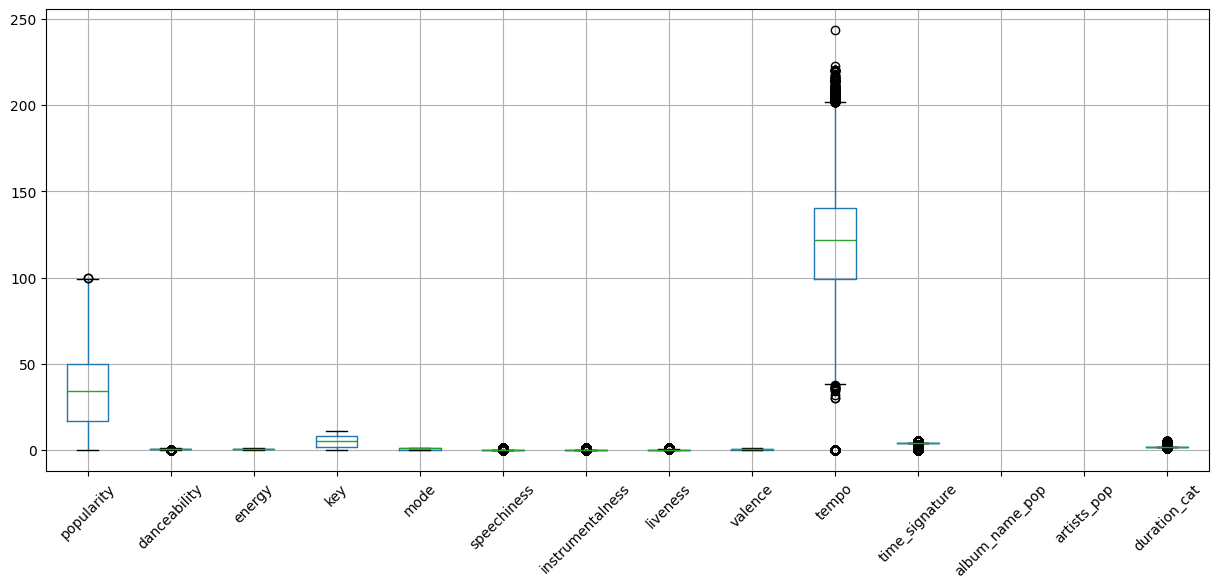

In [18]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(15,6))
num_df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [20]:
print(df['tempo'].min())
print(df['tempo'].max())
print(df['tempo'].mean())

0.0
243.372
122.02996688808652


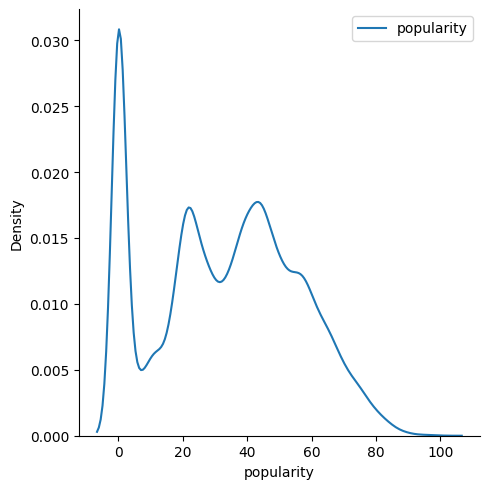

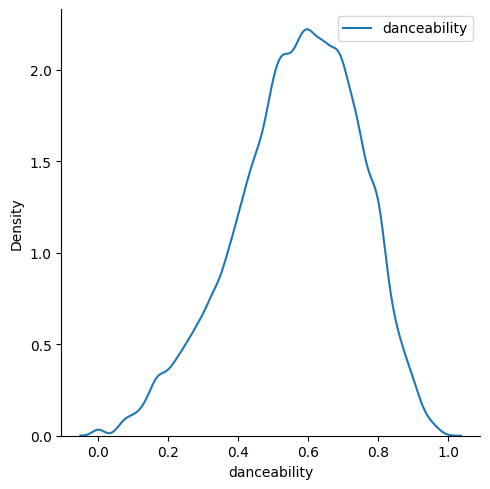

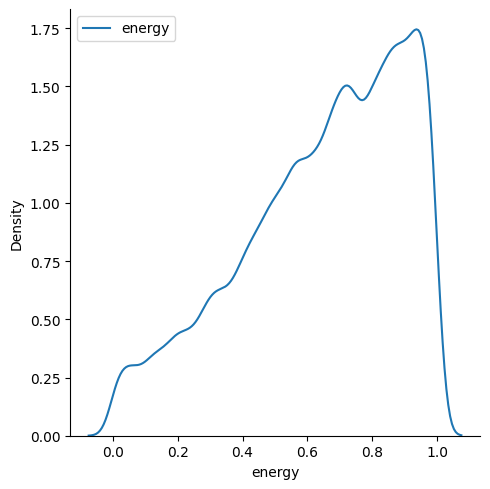

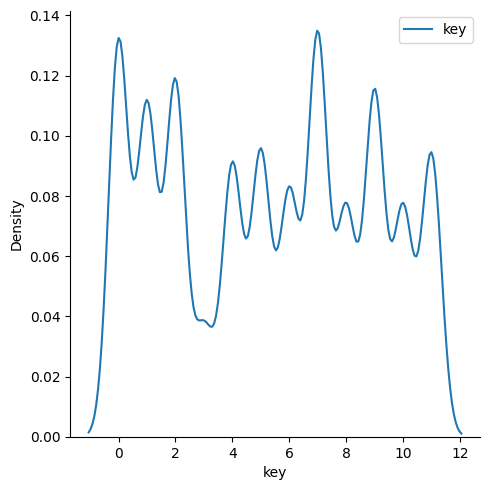

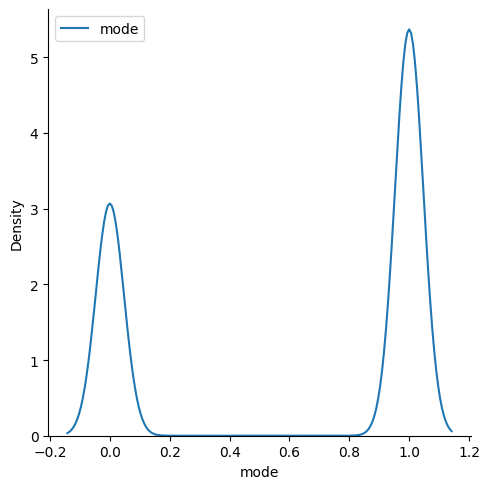

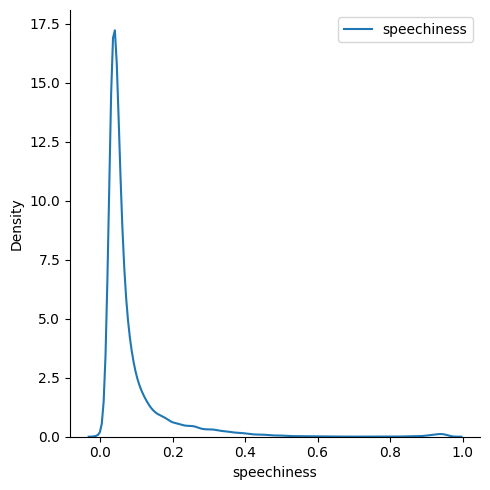

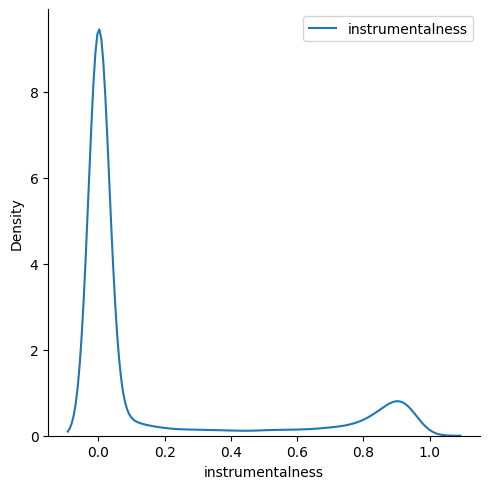

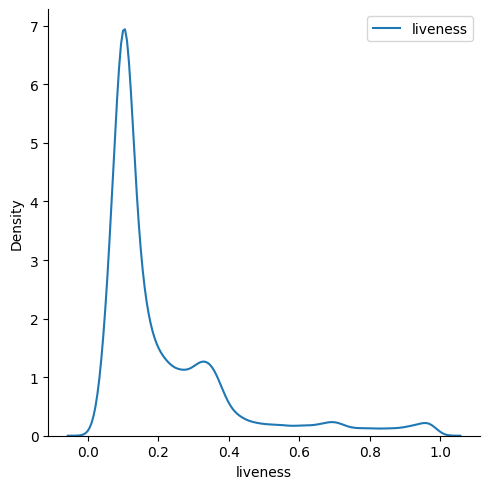

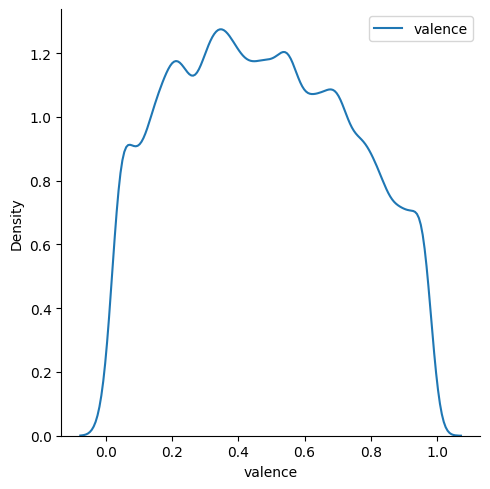

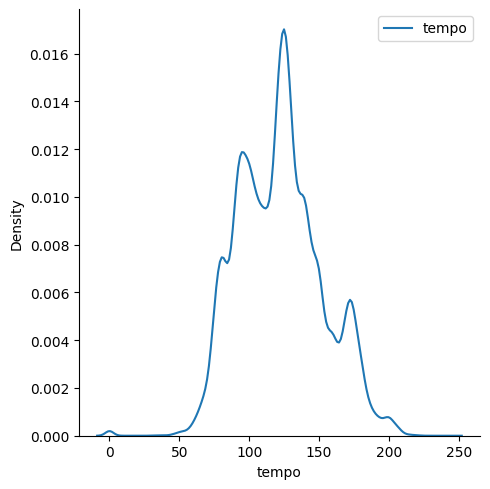

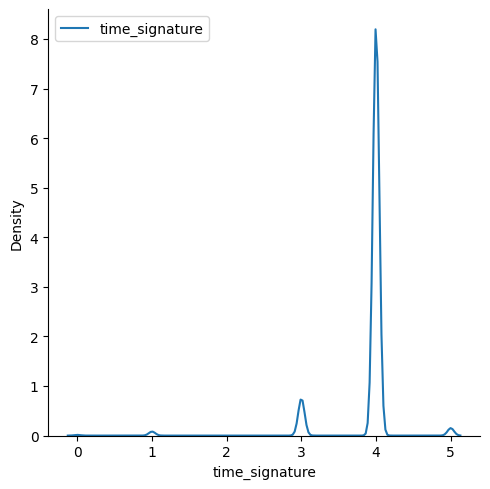

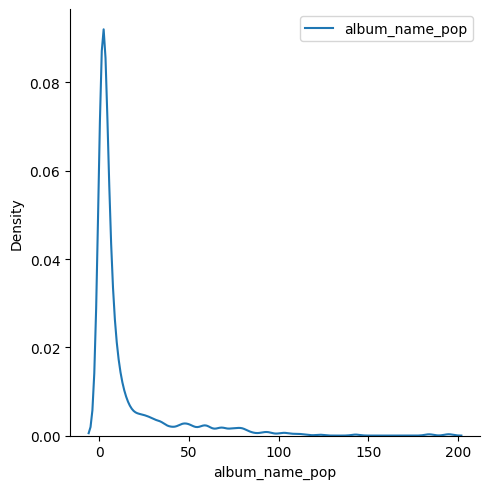

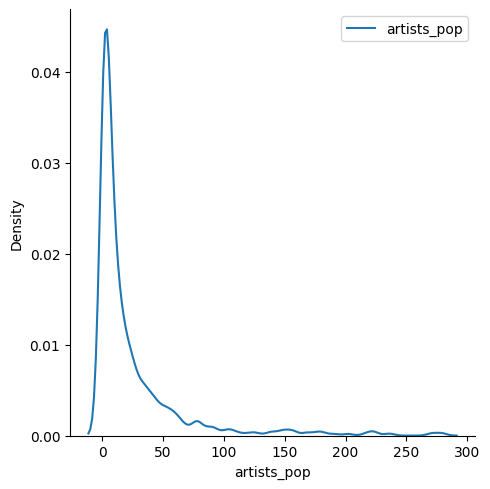

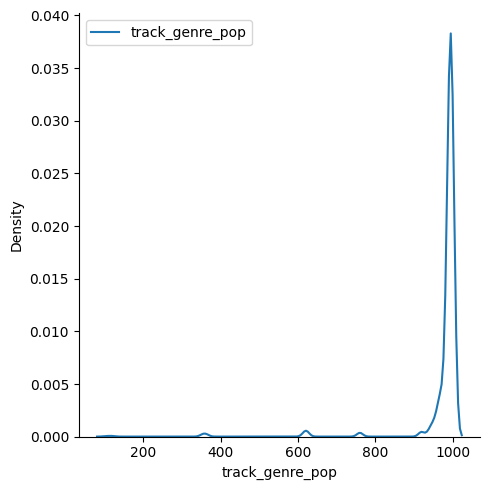

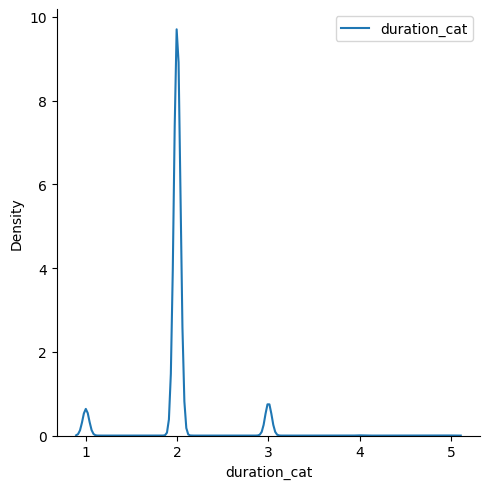

In [76]:
num_df = df.select_dtypes(include='number')
for num_col in num_df.columns:
    sns.displot(data = df, x = num_col, kind = "kde", label = num_col)
    plt.legend()
    plt.show()

In [7]:
num_df = df.select_dtypes(include='number')
num_df.var()

popularity           502.180090
danceability           0.030617
energy                 0.063084
key                   12.694799
mode                   0.231404
speechiness            0.011527
instrumentalness       0.098452
liveness               0.037097
valence                0.068042
tempo                897.317370
time_signature         0.189657
album_name_pop       570.658299
artists_pop         1722.046285
track_genre_pop     6161.222266
duration_cat           0.130063
dtype: float64

In [8]:
print(df['valence'].describe())
print(df['mode'].describe())

count    108843.000000
mean          0.474602
std           0.260848
min           0.000000
25%           0.258000
50%           0.465000
75%           0.685000
max           0.995000
Name: valence, dtype: float64
count    108843.000000
mean          0.636375
std           0.481045
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: mode, dtype: float64


In [10]:
print('danceability')
print(df['danceability'].describe())
print('\nspeechiness')
print(df['speechiness'].describe())
print('\nliveness')
print(df['liveness'].describe())

danceability
count    108843.000000
mean          0.568092
std           0.174976
min           0.000000
25%           0.456000
50%           0.582000
75%           0.698000
max           0.985000
Name: danceability, dtype: float64

speechiness
count    108843.000000
mean          0.085910
std           0.107363
min           0.000000
25%           0.036200
50%           0.049400
75%           0.085900
max           0.965000
Name: speechiness, dtype: float64

liveness
count    108843.000000
mean          0.214886
std           0.192607
min           0.000000
25%           0.097900
50%           0.132000
75%           0.275000
max           1.000000
Name: liveness, dtype: float64


In [12]:
df.drop(columns = ['mode', 'speechiness'], inplace = True)

In [15]:
l = df.columns
print(len(l))
print(l)

15
Index(['track_id', 'popularity', 'explicit', 'danceability', 'energy', 'key',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'album_name_pop', 'artists_pop', 'track_genre_pop', 'duration_cat'],
      dtype='object')


In [16]:
df['time_signature'].describe()

count    108843.000000
mean          3.903512
std           0.435497
min           0.000000
25%           4.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: time_signature, dtype: float64

In [17]:
df['time_signature'].value_counts()

time_signature
4    97185
3     8783
5     1767
1      946
0      162
Name: count, dtype: int64

In [18]:
df.drop(columns = ['time_signature'], inplace = True)

In [20]:
df

,track_id,popularity,explicit,danceability,energy,key,instrumentalness,liveness,valence,tempo,album_name_pop,artists_pop,track_genre_pop,duration_cat
0,5SuOikwiRyPMVoIQDJUgSV,73,False,0.676,0.4610,1,0.000001,0.3580,0.7150,87.917,4,10,940,2
1,4qPNDBW1i3p13qLCt0Ki3A,55,False,0.420,0.1660,1,0.000006,0.1010,0.2670,77.489,2,13,940,2
2,1iJBSr7s7jYXzM8EGcbK5b,57,False,0.438,0.3590,0,0.000000,0.1170,0.1200,76.332,1,1,940,2
3,6lfxq3CG4xtTiEg7opyCyx,71,False,0.266,0.0596,0,0.000071,0.1320,0.1430,181.740,1,15,940,2
4,5vjLSffimiIP26QG5WcN2K,82,False,0.618,0.4430,2,0.000000,0.0829,0.1670,119.949,6,11,940,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108838,2C3TZjDRiAzdyViavDJ217,21,False,0.172,0.2350,5,0.928000,0.0863,0.0339,125.995,4,4,999,3
108839,1hIz5L4IB9hN3WRYPOCGPw,22,False,0.174,0.1170,0,0.976000,0.1050,0.0350,85.239,4,4,999,3
108840,6x8ZfSoqDjuNa5SVP5QjvX,22,False,0.629,0.3290,0,0.000000,0.0839,0.7430,132.378,26,14,999,2
108841,2e6sXL2bYv4bSz6VTdnfLs,41,False,0.587,0.5060,7,0.000000,0.2700,0.4130,135.960,2,30,999,2


In [21]:
df['explicit'].value_counts()

explicit
False    99296
True      9547
Name: count, dtype: int64

In [22]:
df.drop(columns = ['explicit'], inplace = True)

In [23]:
print(df['key'].describe())

count    108843.000000
mean          5.312184
std           3.562976
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          11.000000
Name: key, dtype: float64


In [5]:
print(len(df.columns))
df.columns

13


Index(['track_id', 'popularity', 'danceability', 'energy', 'key',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'album_name_pop',
       'artists_pop', 'track_genre_pop', 'duration_cat'],
      dtype='object')

In [10]:
df = pd.read_csv("df.csv")

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [11]:
pdf = df[:500]

In [12]:
pdf

,track_id,popularity,danceability,energy,key,instrumentalness,liveness,valence,tempo,album_name_pop,artists_pop,track_genre_pop,duration_cat
0,5SuOikwiRyPMVoIQDJUgSV,73,0.676,0.4610,1,0.000001,0.3580,0.715,87.917,4,10,940,2
1,4qPNDBW1i3p13qLCt0Ki3A,55,0.420,0.1660,1,0.000006,0.1010,0.267,77.489,2,13,940,2
2,1iJBSr7s7jYXzM8EGcbK5b,57,0.438,0.3590,0,0.000000,0.1170,0.120,76.332,1,1,940,2
3,6lfxq3CG4xtTiEg7opyCyx,71,0.266,0.0596,0,0.000071,0.1320,0.143,181.740,1,15,940,2
4,5vjLSffimiIP26QG5WcN2K,82,0.618,0.4430,2,0.000000,0.0829,0.167,119.949,6,11,940,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,3BztDPhRhfwdwUndTlg45h,37,0.751,0.5650,5,0.012100,0.0855,0.679,119.996,8,28,940,2
496,27hFQQS3cVUmIK3ser5bpu,34,0.620,0.4680,4,0.000039,0.1060,0.217,110.969,1,2,940,2
497,63F2nWghdifkNHVns5GT8W,53,0.478,0.3980,2,0.018300,0.0826,0.371,159.906,1,19,940,2
498,0lczO04vbk2ZiNvAqzUUQ0,47,0.440,0.1190,10,0.000001,0.1370,0.279,145.186,1,7,940,2


In [13]:
num_df = pdf.drop(columns = ['track_id'])

scaler = StandardScaler()
num_df_scaled = scaler.fit_transform(num_df)

In [14]:
tsne = TSNE(
    n_components = 2,
    random_state = 42,
    perplexity = 30
)

num_df_tsne = tsne.fit_transform(num_df_scaled)

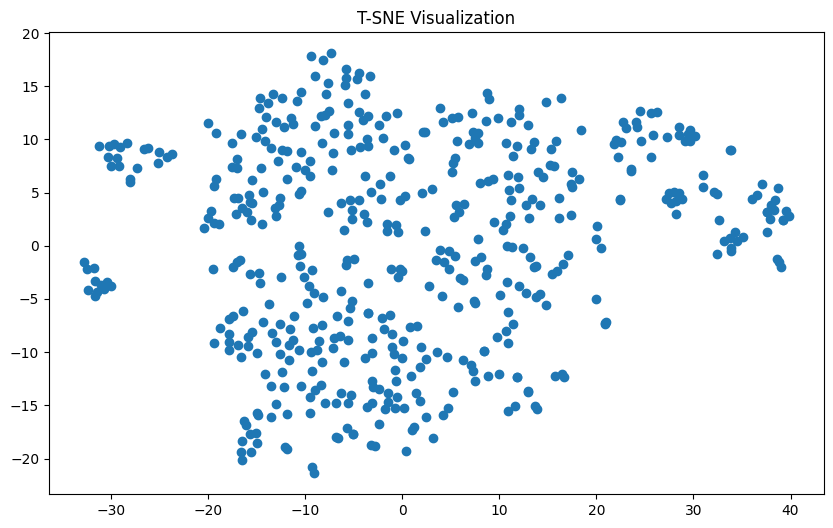

In [15]:
plt.figure(figsize = (10, 6))
scatter = plt.scatter(
    num_df_tsne[:, 0], num_df_tsne[:, 1],
)
plt.title("T-SNE Visualization")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)